              precision    recall  f1-score   support

     Negativ       1.00      0.93      0.96      7141
     Positiv       0.52      0.96      0.68       585

    accuracy                           0.93      7726
   macro avg       0.76      0.94      0.82      7726
weighted avg       0.96      0.93      0.94      7726

[[6629  512]
 [  24  561]]
AUC: 0.986514374079141
Accuracy:  93.06%
FN-rate:   4.10%  (farliga missade fall)
FP-rate:   7.17%  (onödiga larm)
Sensitivitet:   95.90%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   92.83%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9865


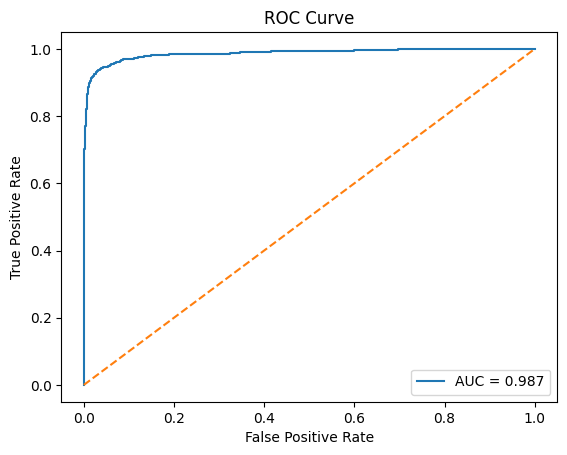

In [12]:
import duckdb
import random
from functions.analyte import ANALYTES
from networks.cnn_maxpooling import CNNModel
from networks.auto_encoder import AutoencoderModel
from functions.evaluation import evaluate
from functions.full_model import predict_inflammation_and_oligoclonal

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 AND observation_nr = 1
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

protein_cols = [a.col for a in ANALYTES[:8]]  # bara de 8 första
df = df.dropna(subset=protein_cols)
y = df['label']

df = df[df['set'] == 'test']
cnn = CNNModel()
ae = AutoencoderModel()
df = cnn.predict(df)
df = ae.predict(df)
df = predict_inflammation_and_oligoclonal(df)
df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold=0.1,proportion=50)

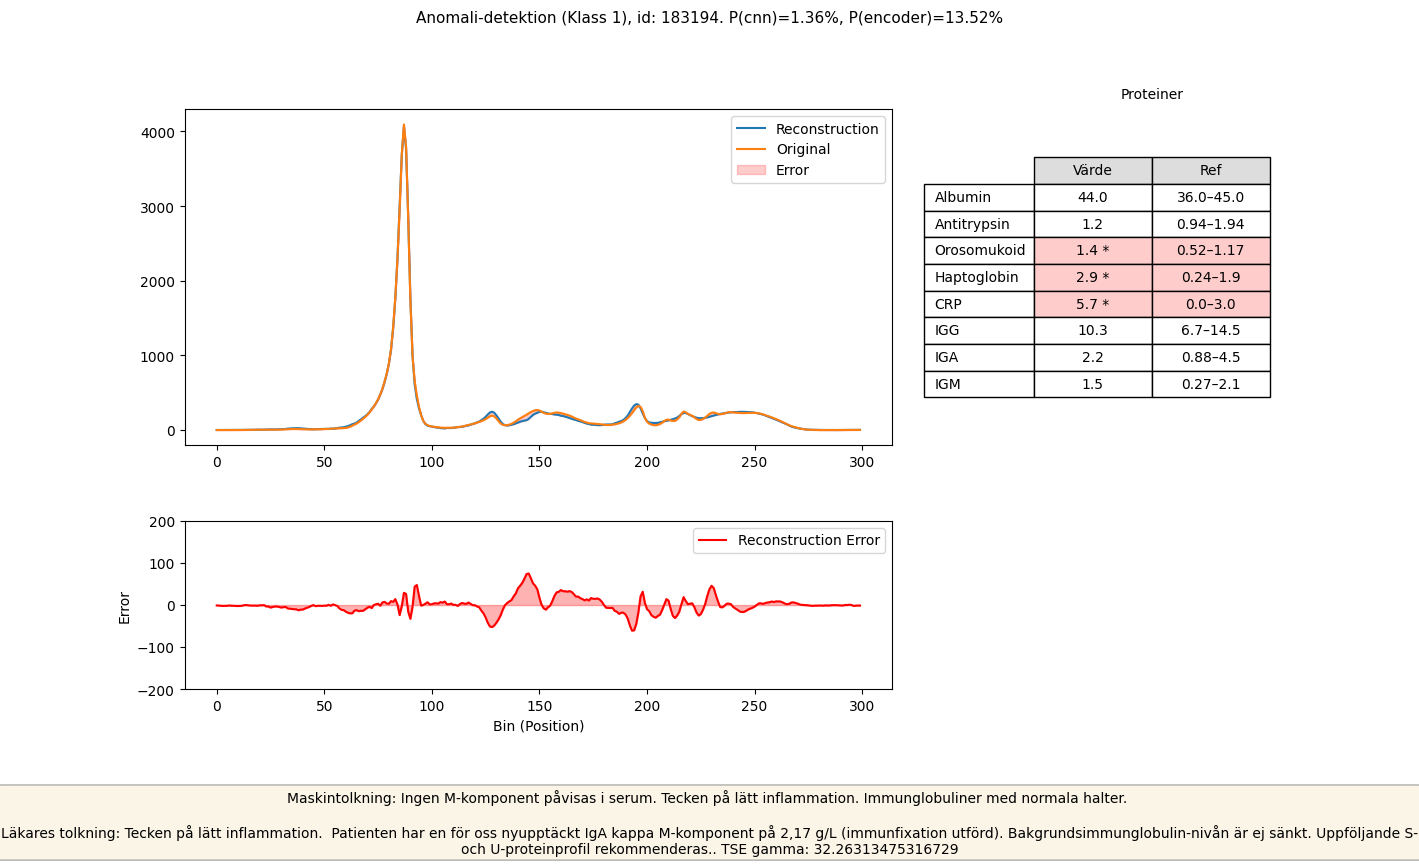

In [ ]:
import importlib
import functions.full_model as full_model
importlib.reload(full_model)
from functions.full_model import interpret


#df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold = 0.15,proportion=50)

#df['prediction'] = ((df['cnn_probability'] > 0.15) | (df['proportion_gamma_region'] > 0.5)).astype(int)

#rows = processed_rows[processed_rows['proportion_gamma_region'] > 0.9].sort_values('proportion_gamma_region',ascending=False)
df = df[(df['cnn_probability'] < 0.1) & (df['label'] == 1)].sort_values('cnn_probability',ascending=True)
row = df.iloc[10,:]
#row = test_rows.iloc[idx,:]
result = interpret(row.to_dict())

